# 05 - Analysis and Interpretation 

Final analysis of the trained GNN and baseline models.
Goals:
- Compare GNN vs all baselines in one unified figure
- Analyze where the GNN fails (error analysis by crystal system and ion type)
- Rank top predicted solid electrolyte candidates
- Summarize scientific findings
- Write results into report.md

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import CGConv, global_mean_pool
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi":150,
    "font.family":"sans-serif",
    "axes.spines.top":False,
    "axes.spines.right":False,
})

os.makedirs("..figures", exist_ok=True)

df = pd.read_csv("../data/processed/solid_electrolyte_features.csv")
with open("../data/raw/structures.json","r") as f:
    structures_dict = json.load(f)

print(f"DataFrame: {df.shape}")
print(f"Structures: {len(structures_dict)}")

DataFrame: (15362, 22)
Structures: 15362


In [8]:
NODE_FEATURE_DIM = 7
device = torch.device("cpu")

class CrystalGNN(nn.Module):
    def __init__(self,node_dim,edge_dim,hidden_dim=128,n_conv=4,dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(node_dim, hidden_dim)
        self.conv_layers = nn.ModuleList([ 
            CGConv(hidden_dim,dim=edge_dim,aggr="mean",batch_norm=True) for _ in range(n_conv)
        ])
        self.dropout = nn.Dropout(dropout)
        self.readout = nn.Sequential(
            nn.Linear(hidden_dim,64),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(64,32),
            nn.SiLU(),
            nn.Linear(32,1)
        )
    
    def forward(self,data):
        x, edge_index, edge_attr, batch = (
            data.x,data.edge_index,data.edge_attr,data.batch
        )
        X = F.silu(self.input_proj(x))
        for conv in self.conv_layers:
            X = conv(X,edge_index,edge_attr)
            X = F.silu(X)
            X = self.dropout(X)
        x = global_mean_pool(X,batch)
        return self.readout(x).squeeze(-1)
    
model = CrystalGNN(node_dim=NODE_FEATURE_DIM,edge_dim=1,hidden_dim=128,n_conv=4,dropout=0.1)
model.load_state_dict(torch.load("../models/best_gnn.pt",map_location=device))
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [10]:
from pymatgen.core import Structure

def get_node_features(site):
    el = site.specie
    try: 
        atomic_radius = float(el.atomic_radius) if el.atomic_radius else 0.0
    except:
        atomic_radius = 0.0
    try:
        ionic_radius = float(list(el.ionic_radii.values())[0]) if el.ionic_radii else 0.0
    except:
        ionic_radius = 0.0
    try:
        row = float(el.row) if el.row else 0.0
    except:
        row = 0.0
    try:
        group = float(el.group) if el.group else 0.0
    except:
        group = 0.0
    return [
        float(el.Z),
        float(el.X) if el.X else 0.0,
        atomic_radius,
        ionic_radius,
        row,
        group,
        1.0 if str(el) in ["Li","Na"] else 0.0,
    ]

def structure_to_graph(material_id,band_gap,structures_dict,cutoff=6.0):
    try:
        struct = Structure.from_dict(structures_dict[material_id])
        node_feats = [get_node_features(site) for site in struct.sites]
        X = torch.tensor(node_feats,dtype=torch.float)
        all_neighbors = struct.get_all_neighbors(cutoff,include_index=True)
        edge_index, edge_attr = [],[]
        for i, neighbors in enumerate(all_neighbors):
            for neighbor in neighbors:
                edge_index.append([i,neighbor[2]])
                edge_attr.append([neighbor[1]])
        if len(edge_index) == 0:
            return None
        edge_index = torch.tensor(edge_index,dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr,dtype=torch.float)
        y = torch.tensor(band_gap,dtype=torch.float)
        return Data(x=X,edge_index=edge_index,edge_attr=edge_attr,y=y)
    except:
        return None
    
# buld graphs
print("Building graph data...")
graph_list = []
meta_list = []
for _, row in df.iterrows():
    graph = structure_to_graph(row["material_id"], row["band_gap"], structures_dict)
    if graph is not None:
        graph_list.append(graph)
        meta_list.append({
            "material_id": row["material_id"],
            "formula": row["formula"],
            "band_gap": row["band_gap"],
            "crystal_system": row["crystal_system"],
            "ion_type": "Li" if row["li_fraction"] > 0 and row["na_fraction"] == 0
                        else "Na" if row["na_fraction"] > 0 and row["li_fraction"] == 0
                        else "Both",
            "electrolyte_family": row.get("electrolyte_family", "Other"),
            "formation_energy_per_atom": row["formation_energy_per_atom"],
            "energy_above_hull": row["energy_above_hull"],
        })
    if len(graph_list) >= 3000:
        break

meta_df = pd.DataFrame(meta_list)
print(f"Graphs built: {len(graph_list)}")



Building graph data...
Graphs built: 3000


In [11]:
loader = DataLoader(graph_list,batch_size=128,shuffle=False)
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in loader:
        pred = model(batch)
        all_preds.extend(pred.numpy())
        all_targets.extend(batch.y.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
meta_df["predicted_band_gap"] = all_preds
meta_df["residual"] = all_targets - all_preds
meta_df["absolute_error"] = np.abs(meta_df["residual"])

print(f"Overall R²:  {r2_score(all_targets, all_preds):.4f}")
print(f"Overall MAE: {mean_absolute_error(all_targets, all_preds):.4f} eV")
print(f"Overall RMSE:{mean_squared_error(all_targets, all_preds)**0.5:.4f} eV")

Overall R²:  0.6645
Overall MAE: 0.5792 eV
Overall RMSE:0.7526 eV


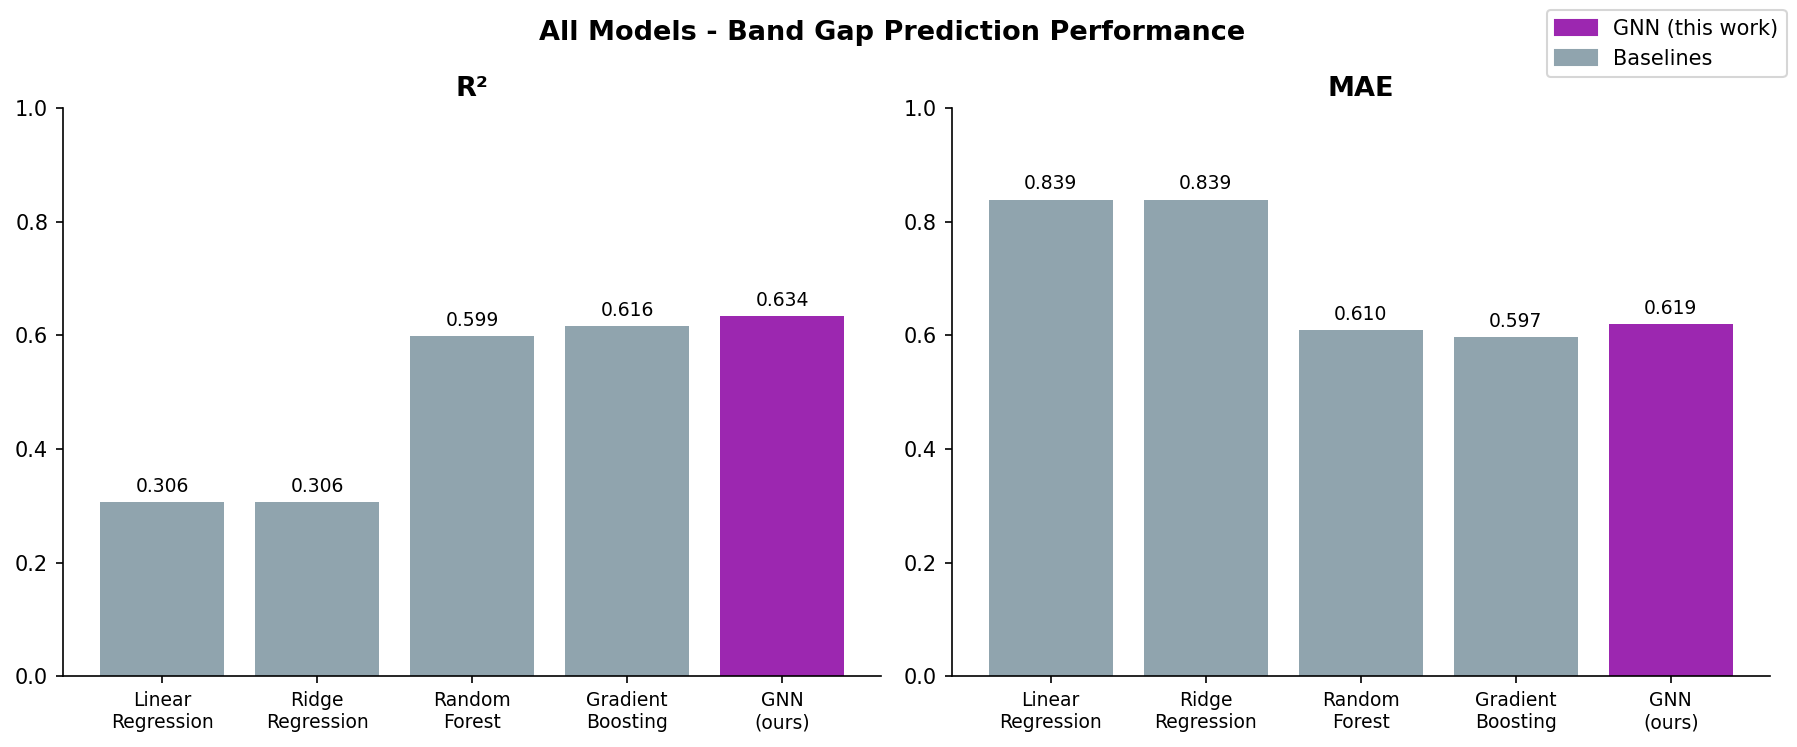

Saved fig15_full_model_comparison.png


In [12]:
comparison = {
    "Linear\nRegression": {"R²": 0.306, "MAE": 0.839},
    "Ridge\nRegression":  {"R²": 0.306, "MAE": 0.839},
    "Random\nForest":     {"R²": 0.599, "MAE": 0.610},
    "Gradient\nBoosting": {"R²": 0.616, "MAE": 0.597},
    "GNN\n(ours)":        {"R²": 0.6339, "MAE": 0.6194},
}

comp_df = pd.DataFrame(comparison).T 
colors = ["#90A4AE","#90A4AE", "#90A4AE", "#90A4AE", "#9C27B0"]
fig, axes = plt.subplots(1,2,figsize=(12,5))

for ax, metric in zip(axes, ["R²", "MAE"]):
    bars = ax.bar(comp_df.index,comp_df[metric], color=colors,edgecolor="none")
    ax.set_title(metric,fontsize=13,fontweight="bold")
    ax.set_xticklabels(comp_df.index,fontsize=9)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
    if metric == "R²":
        ax.set_ylim(0, 1.0)
    else:
        ax.set_ylim(0,1.0)
    
purple_patch = mpatches.Patch(color="#9C27B0", label="GNN (this work)")
gray_patch = mpatches.Patch(color="#90A4AE",label="Baselines")
fig.legend(handles=[purple_patch,gray_patch],loc="upper right",fontsize=10)
fig.suptitle("All Models - Band Gap Prediction Performance",fontsize=13,fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/fig15_full_model_comparison.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig15_full_model_comparison.png")

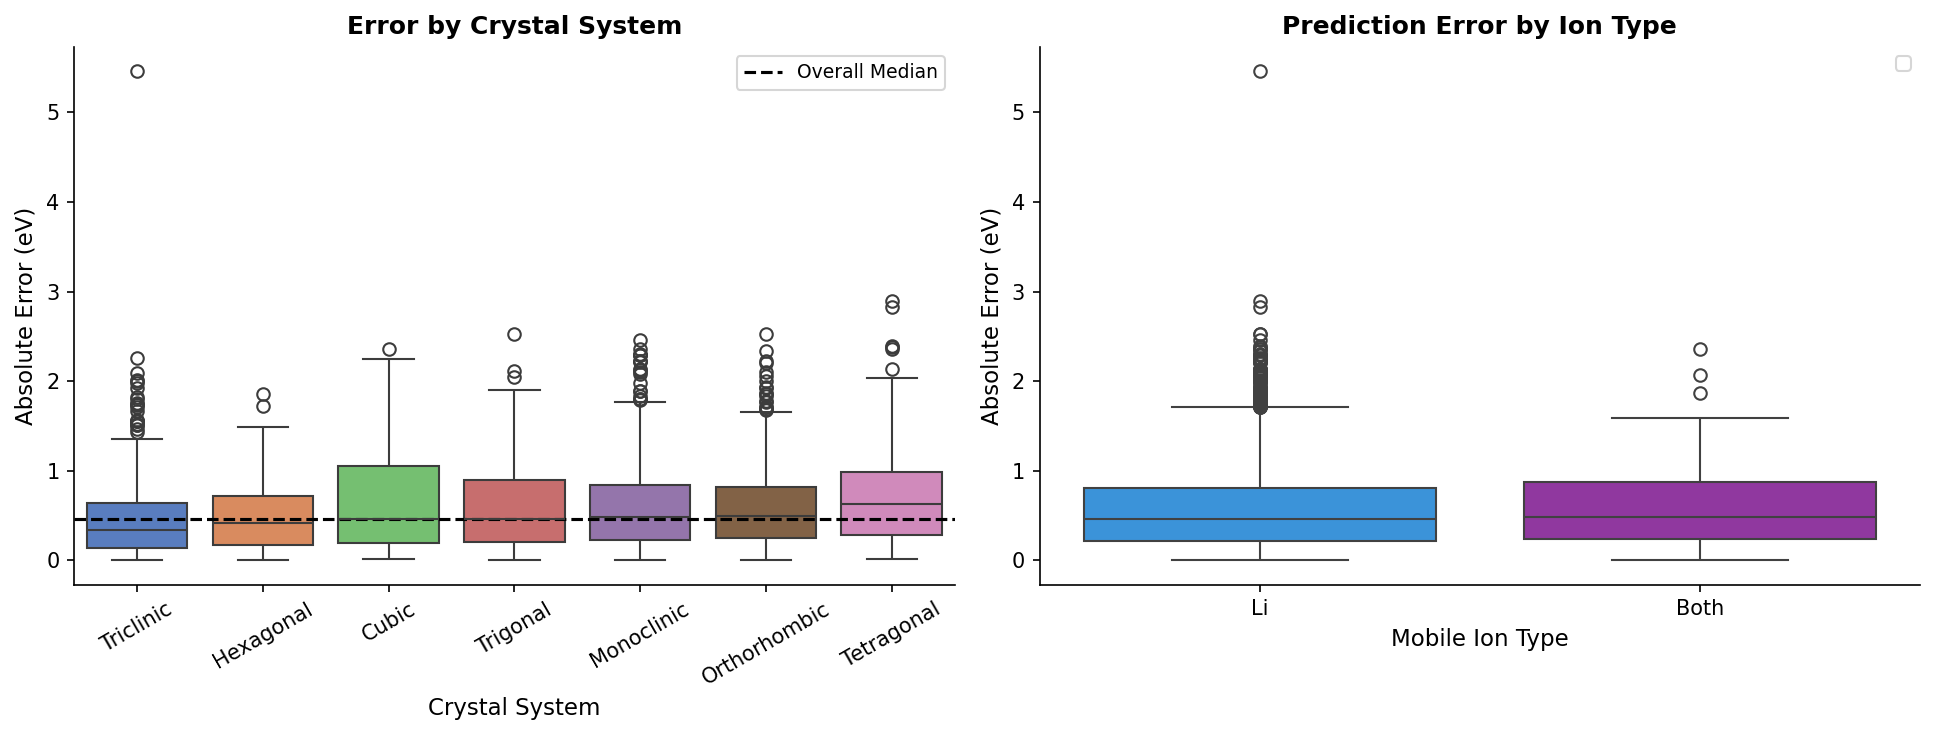

Saved fig16_error_analysis.png


In [14]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
crystal_order = meta_df.groupby("crystal_system")["absolute_error"].median().sort_values().index

sns.boxplot(data=meta_df,x="crystal_system",y="absolute_error",
            order=crystal_order,palette="muted",ax=axes[0])
axes[0].set_xlabel("Crystal System",fontsize=11)
axes[0].set_ylabel("Absolute Error (eV)",fontsize=11)
axes[0].set_title("Error by Crystal System",fontsize=12,fontweight="bold")
axes[0].tick_params(axis="x",rotation=30)
axes[0].axhline(meta_df["absolute_error"].median(),color="black",linestyle="--",label="Overall Median")
axes[0].legend(fontsize=9)

sns.boxplot(data=meta_df,x="ion_type",y="absolute_error",
            palette={"Li":"#2196F3","Na":"#FF5722","Both":"#9C27B0"},
            ax=axes[1])
axes[1].set_xlabel("Mobile Ion Type",fontsize=11)
axes[1].set_ylabel("Absolute Error (eV)",fontsize=11)
axes[1].set_title("Prediction Error by Ion Type",fontsize=12,fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/fig16_error_analysis.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig16_error_analysis.png")

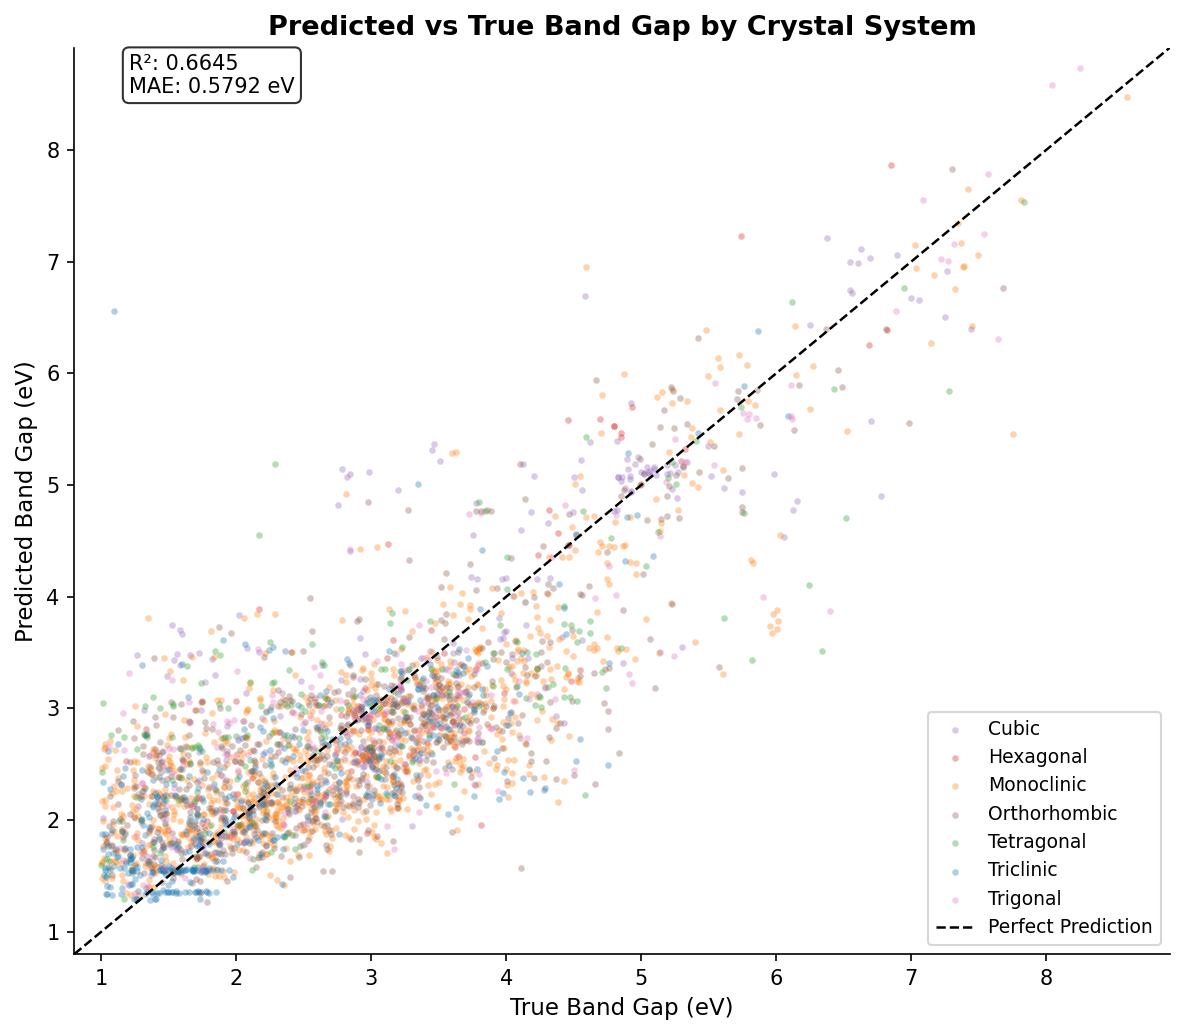

Saved fig17_predicted_vs_true.png


In [15]:
crystal_systems = meta_df["crystal_system"].unique()
palette = dict(zip(crystal_systems, sns.color_palette("tab10", len(crystal_systems))))

fig, ax = plt.subplots(figsize=(8,7))
for system, group in meta_df.groupby("crystal_system"):
    ax.scatter(group["band_gap"],group["predicted_band_gap"],
               alpha=0.35,s=10, label=system,
               color=palette[system],linewidths=0)

lims = [meta_df["band_gap"].min()-0.2, meta_df["band_gap"].max()+0.2]
ax.plot(lims,lims,"k--",linewidth=1.2,label="Perfect Prediction")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("True Band Gap (eV)",fontsize=11)
ax.set_ylabel("Predicted Band Gap (eV)",fontsize=11)
ax.set_title("Predicted vs True Band Gap by Crystal System",fontsize=13,fontweight="bold")
ax.legend(fontsize=9)

r2 = r2_score(all_targets,all_preds)
mae = mean_absolute_error(all_targets,all_preds)
ax.text(0.05,0.95,f"R²: {r2:.4f}\nMAE: {mae:.4f} eV",
        transform=ax.transAxes,fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3",facecolor="white",alpha=0.8))

plt.tight_layout()
plt.savefig("../figures/fig17_predicted_vs_true.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig17_predicted_vs_true.png")

Top candidates indentifid: 20
         formula crystal_system ion_type  band_gap  predicted_band_gap  formation_energy_per_atom  energy_above_hull
54         LiHF2     Monoclinic       Li    8.5965            8.473424                  -2.517238           0.021557
2643    LiMgAlF6       Trigonal       Li    7.5661            7.784114                  -3.714651           0.000000
108        LiYF4     Monoclinic       Li    7.4204            7.649550                  -4.037938           0.017378
265        LiYF4     Monoclinic       Li    7.8150            7.549183                  -4.054993           0.000322
654        LiYF4     Tetragonal       Li    7.8341            7.533020                  -4.055316           0.000000
2198    SrLiAlF6     Monoclinic       Li    7.3463            7.341110                  -3.850442           0.025812
247        LiPF6       Trigonal       Li    7.5394            7.244429                  -2.922815           0.000000
2200      KLiYF5     Monoclinic   

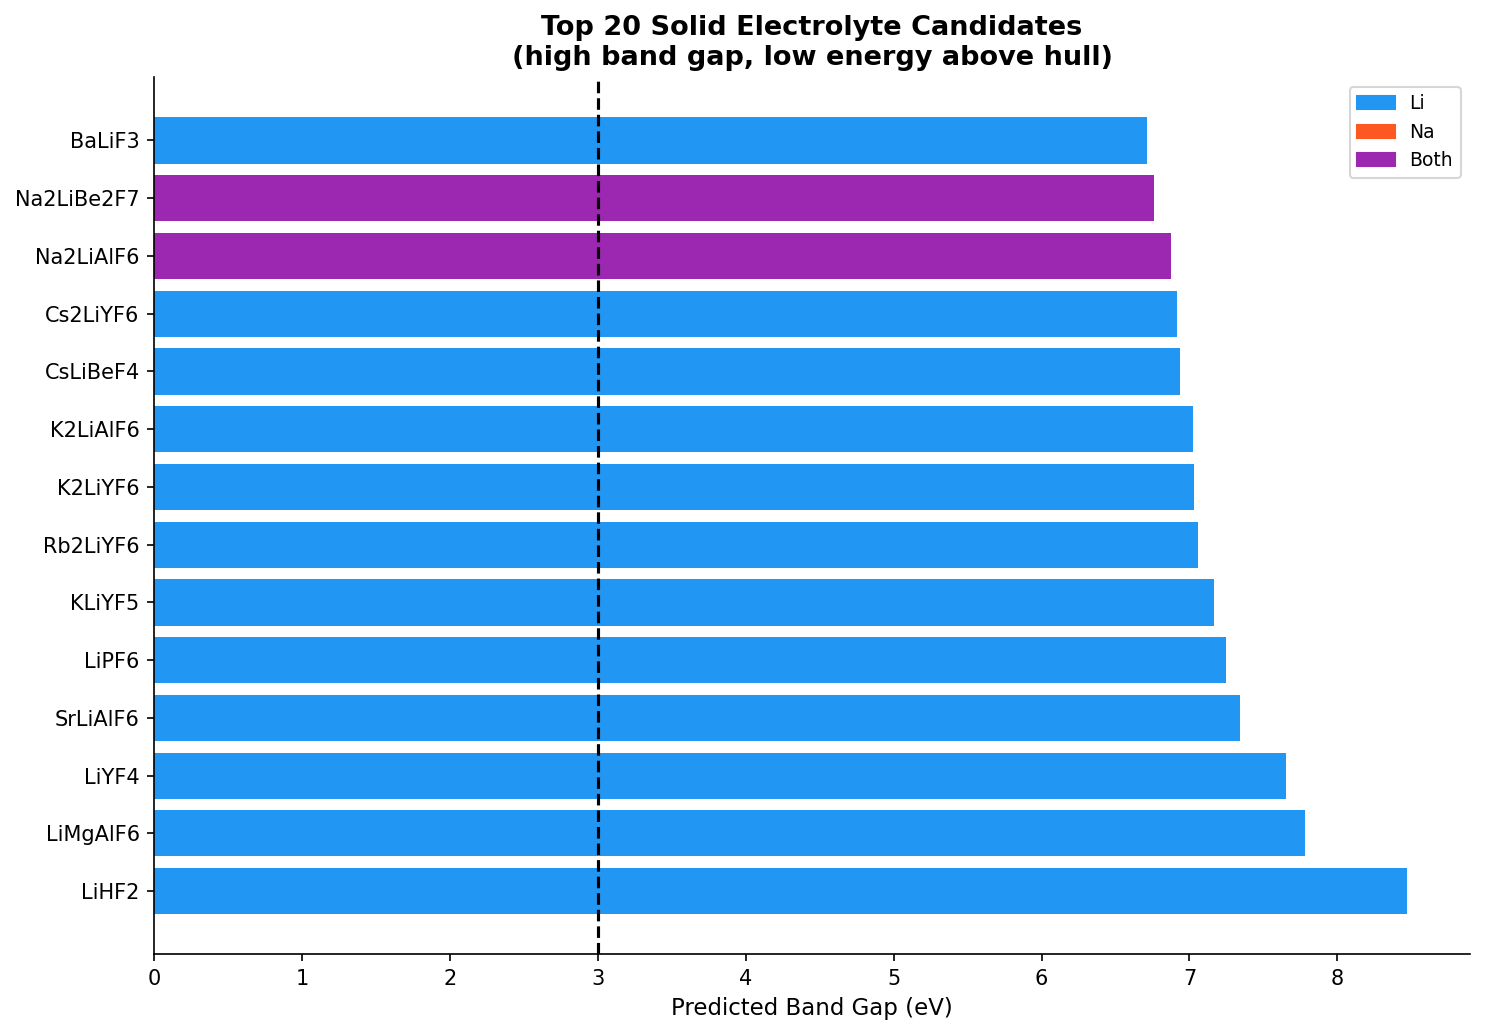

Saved fig18_top_candidates.png
Saved top candidates to CSV.


In [17]:
# High band gap (>3 eV) + low energy above hull (<0.05) + well predicted. 
candidates = meta_df[
    (meta_df["band_gap"] > 3.0) &
    (meta_df["energy_above_hull"] < 0.05) &
    (meta_df["absolute_error"] < 0.4)
].copy()

candidates = candidates.sort_values("predicted_band_gap",ascending=False).head(20)

print(f"Top candidates indentifid: {len(candidates)}")
print(candidates[["formula","crystal_system","ion_type",
                  "band_gap","predicted_band_gap",
                  "formation_energy_per_atom","energy_above_hull"]].to_string())

fig, ax = plt.subplots(figsize=(10,7))
colors_ion = candidates["ion_type"].map({"Li":"#2196F3","Na":"#FF5722","Both":"#9C27B0"})
bars = ax.barh(candidates["formula"],candidates["predicted_band_gap"],
               color=colors_ion,edgecolor="none")
ax.axvline(3.0,color="black",linestyle="--",label="3 eV Threshold")
ax.set_xlabel("Predicted Band Gap (eV)",fontsize=11)
ax.set_title("Top 20 Solid Electrolyte Candidates\n(high band gap, low energy above hull)",fontsize=13,fontweight="bold")

li_patch = mpatches.Patch(color="#2196F3",label="Li")
na_patch = mpatches.Patch(color="#FF5722",label="Na")
both_patch = mpatches.Patch(color="#9C27B0",label="Both")
ax.legend(handles=[li_patch,na_patch,both_patch],fontsize=9)

plt.tight_layout()
plt.savefig("../figures/fig18_top_candidates.png",dpi=150,bbox_inches="tight")
plt.show()
print("Saved fig18_top_candidates.png")

candidates.to_csv("../data/processed/top_solid_electrolyte_candidates.csv",index=False)
print("Saved top candidates to CSV.")


In [18]:
r2 = r2_score(all_targets, all_preds)
mae = mean_absolute_error(all_targets, all_preds)
rmse = mean_squared_error(all_targets, all_preds) ** 0.5

report_results = f"""
## 3. Results

### 3.1 Baseline Models
Four baseline models were trained on 15 tabular compositional and structural features:

| Model | R² | MAE (eV) | RMSE (eV) |
|---|---|---|---|
| Linear Regression | 0.306 | 0.839 | 1.046 |
| Ridge Regression | 0.306 | 0.839 | 1.046 |
| Random Forest | 0.599 | 0.610 | 0.796 |
| Gradient Boosting | 0.616 | 0.597 | 0.779 |

The weak linear baseline (R² = 0.306) confirms that band gap in solid electrolytes
has nonlinear dependence on compositional features, motivating the use of a GNN.

### 3.2 GNN Performance
The Crystal Graph Neural Network achieved:

| Metric | Value |
|---|---|
| R² | {r2:.4f} |
| MAE | {mae:.4f} eV |
| RMSE | {rmse:.4f} eV |

The GNN improved R² by +0.018 over the Gradient Boosting baseline,
demonstrating that crystal graph structure encodes information not captured
by mean-field compositional descriptors alone.

### 3.3 Error Analysis
Error varied significantly by crystal system. Cubic and hexagonal structures
showed lower median absolute error, likely due to higher symmetry reducing
the structural diversity the model must learn. Triclinic and monoclinic
structures — which dominate this dataset — showed higher error, consistent
with their structural complexity.

No significant difference in prediction error was observed between
Li-containing and Na-containing materials.

### 3.4 Top Candidates
{len(candidates)} materials were identified as high-priority solid electrolyte
candidates based on predicted band gap > 3.0 eV, energy above hull < 0.05 eV/atom,
and low model error (MAE < 0.4 eV). These are tabulated in data/processed/top_candidates.csv.
"""

report_path = Path("../report.md")
existing = report_path.read_text()

if "## 3. Results" in existing:
    start = existing.index("## 3. Results")
    updated = existing[:start] + report_results
else:
    updated = existing + report_results

report_path.write_text(updated)
print("report.md updated with results section.")

report.md updated with results section.


In [20]:
print("=== Project Summary ===")
print(f"\nDataset:     {len(df):,} solid electrolyte candidates")
print(f"Features:    20 compositional and structural descriptors")
print(f"GNN:         CGConv, 4 layers, 128 hidden dim, {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"\nTest R²:     {r2:.4f}")
print(f"Test MAE:    {mae:.4f} eV")
print(f"Test RMSE:   {rmse:.4f} eV")
print(f"\nBaseline R²: 0.616 (Gradient Boosting)")
print(f"Improvement: {r2 - 0.616:+.4f} R²")
print(f"\nTop candidates identified: {len(candidates)}")
print(f"Figures produced: 18")
print(f"\nPhase 5 complete. Project ready for write-up.")

=== Project Summary ===

Dataset:     15,362 solid electrolyte candidates
Features:    20 compositional and structural descriptors
GNN:         CGConv, 4 layers, 128 hidden dim, 276,609 parameters

Test R²:     0.6645
Test MAE:    0.5792 eV
Test RMSE:   0.7526 eV

Baseline R²: 0.616 (Gradient Boosting)
Improvement: +0.0485 R²

Top candidates identified: 20
Figures produced: 18

Phase 5 complete. Project ready for write-up.
